# Detecting Out-of-Regime Hours

#### Identify hours whose price departs sharply from the recent typical price for that hour-of-day.

##### Constructing the per-hour deviation score

Detecting anomalous prices requires a method that judges each price relative to what is normal for that hour  rather than against a single market-wide standard. A hard threshold of, say, `$200/MWh` and a fixed percentile cutoff strip away this context, since neither provides a local baseline. A flat dollar threshold ignores the prevailing regime: `$200/MWh` is a dramatic deviation in a month where the hour normally clears at `$50/MWh`, but unremarkable in a month where it normally clears at `$180/MWh`. A global percentile of the raw prices has the opposite problem, it simply selects the highest-priced hours across the whole sample, flagging expensive hours rather than anomalous ones.

Earlier observations motivate an alternative. There is strong structure between hour-of-day and price, and for the most part, prices behave normally, with a small set of hours behaving as outliers. We use this to construct a per-hour baseline.

Each price is therefore normalized against what is normal for that specific hour. The median is preferred over the mean for the baseline, so that the reference level is itself robust to the outliers we are trying to detect. For each observation $i$ (grouped by hour-of-day), the baseline is the median of the 28 preceding observations, with the current observation excluded, so the score never depends on the point being judged:
$$
\tilde{m}_i = \operatorname{median}\{x_{i-28}, \ldots, x_{i-1}\}
$$
giving a residual $r_i = x_i - \tilde{m}_i$.

To judge whether a deviation is meaningful, we compare its size to the hour's normal movement using the median of the prior 28 absolute residuals:
$$
\text{MAD}_i = \operatorname{median}\{\,|r_{i-28}|, \ldots, |r_{i-1}|\,\}
$$
This measures the move against how tightly the hour has recently behaved. The final robust score is
$$
z_i = \frac{r_i}{\text{MAD}_i}
$$
where the denominator is floored at `1/MWh` to prevent the score from exploding during flat stretches when recent residuals are near zero. This score is a *relative, per-hour-normalized* measure of how far an hour sits from its own recent baseline, that is, a larger score means a more pronounced departure, so it is used to rank and flag hours, not to quantify the size of an event. Empirically the distribution is heavily right-skewed which is why the score is treated as a relative ranking rather than a calibrated magnitude.

The window spans the 28 most recent prior observations for each hour-of-day, approximately one month of trailing history, to balance two competing needs: a window long enough for the median to rest on a stable set of observations, and short enough that the baseline tracks the substantial shifts in price level over time rather than lagging them.

In [198]:
import pandas as pd
import duckdb as ddb
import matplotlib.pyplot as plt
import numpy as np

ActualForecast = pd.read_csv('ActualForecastData.csv', parse_dates=['date_he'])
backfill = pd.read_csv('backfill_2022_clean.csv', parse_dates=['date_he'])

ActualForecast = (
    pd.concat([backfill, ActualForecast], ignore_index=True)
    .drop_duplicates('date_he')      # in case backfill and main overlap at the seam
    .sort_values('date_he')
    .reset_index(drop=True)
)

print("rows:", len(ActualForecast))
print("range:", ActualForecast['date_he'].min(), "->", ActualForecast['date_he'].max())
print("date_he unique:", ActualForecast['date_he'].is_unique)

gap = ActualForecast['date_he'].diff().max()
print("largest gap:", gap)
print("gaps over 1h:", (ActualForecast['date_he'].diff() > pd.Timedelta('1h')).sum())

d = ActualForecast['date_he'].diff()
gaps = ActualForecast.loc[d > pd.Timedelta('1h'), ['date_he']].copy()
gaps['gap'] = d[d > pd.Timedelta('1h')]
gaps['prev'] = gaps['date_he'] - gaps['gap']
print(gaps[['prev', 'date_he', 'gap']].to_string(index=False))

d = ActualForecast['date_he'].diff()
print((d > pd.Timedelta('1h')).sum(), "gaps > 1h")
print(d[d > pd.Timedelta('1h')])   # full list, no truncation

bf = ActualForecast[ActualForecast['date_he'] < '2023-01-01']
print(bf.groupby(bf['date_he'].dt.hour).size().min(), "min obs per hour")

rows: 31580
range: 2022-11-01 01:00:00 -> 2026-06-09 00:00:00
date_he unique: True
largest gap: 0 days 02:00:00
gaps over 1h: 4
               prev             date_he             gap
2023-03-12 01:00:00 2023-03-12 03:00:00 0 days 02:00:00
2024-03-10 01:00:00 2024-03-10 03:00:00 0 days 02:00:00
2025-03-09 01:00:00 2025-03-09 03:00:00 0 days 02:00:00
2026-03-08 01:00:00 2026-03-08 03:00:00 0 days 02:00:00
4 gaps > 1h
3145    0 days 02:00:00
11880   0 days 02:00:00
20615   0 days 02:00:00
29350   0 days 02:00:00
Name: date_he, dtype: timedelta64[us]
60 min obs per hour


a index unique: True
b index unique: True
overlap: 30117
a only: 0
b only: 0
non-NaN comparisons: 30117
max abs diff: 0.0
c index unique: True
d index unique: True
overlap: 29445
c only: 672
d only: 0
non-NaN comparisons: 29445
max abs diff: 0.0
<class 'pandas.DataFrame'>
RangeIndex: 30117 entries, 0 to 30116
Data columns (total 5 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   date_he                    30117 non-null  datetime64[us]
 1   actual_price               30117 non-null  float64       
 2   same_hour_28_obs_roll_med  30117 non-null  float64       
 3   same_hour_28_obs_roll_MAD  30117 non-null  float64       
 4   median_deviation_score     30117 non-null  float64       
dtypes: datetime64[us](1), float64(4)
memory usage: 1.1 MB
None
start: 2023-01-01 00:00:00 | end: 2026-06-09 00:00:00


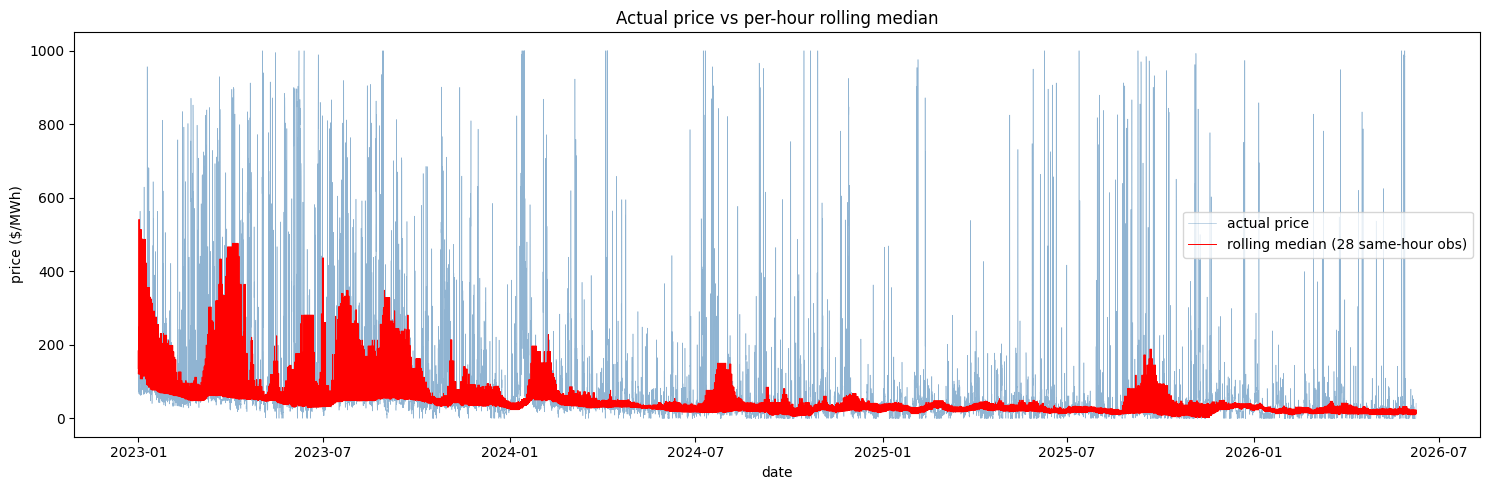

In [199]:
price_rolling_median = ddb.sql('''
    with roll_window as (
        select
            date_he,
            actual_price,
            row_number() over (
                partition by hour(date_he) order by date_he
                ) as rn,  -- per-hour counter
            quantile_cont(actual_price, 0.5) over (
                partition by hour(date_he)
                order by date_he
                rows between 28 preceding and 1 preceding --rolling window, not including the current value
                ) as same_hour_28_obs_roll_med
        from ActualForecast
    ),
    roll_MAD as (
        select
            *,
            quantile_cont(abs(actual_price - same_hour_28_obs_roll_med), 0.5) over (
                partition by hour(date_he)
                order by date_he
                rows between 28 preceding and 1 preceding
            ) as same_hour_28_obs_roll_MAD -- median absolute deviation
        from roll_window
    )
    select
        date_he,
        actual_price,
        same_hour_28_obs_roll_med,
        same_hour_28_obs_roll_MAD,
        (actual_price - same_hour_28_obs_roll_med) / same_hour_28_obs_roll_MAD as median_deviation_score
    from roll_MAD
    where date_he >= '2023-01-01'
    order by date_he
    ''').df()

# Check that the rolling median is computed correctly
check_med = ActualForecast[['date_he', 'actual_price']].copy()

check_med['roll_med'] = (
    ActualForecast
    .groupby(ActualForecast['date_he'].dt.hour)['actual_price']
    .transform(lambda s: s.shift(1).rolling(28).median()) # preserve original df while adding new column
)
check_med = check_med[check_med['date_he'] >= '2023-01-01']
a = price_rolling_median.set_index('date_he')['same_hour_28_obs_roll_med']
b = check_med.set_index('date_he')['roll_med'].dropna()

# 1. Indexes must be unique, or alignment fans out / misbehaves
print("a index unique:", a.index.is_unique)
print("b index unique:", b.index.is_unique)

# 2. How many labels actually overlap? (this is what gets compared)
print("overlap:", a.index.intersection(b.index).size)
print("a only:", a.index.difference(b.index).size)
print("b only:", b.index.difference(a.index).size)

diff = (a - b).abs()
print("non-NaN comparisons:", diff.notna().sum())
print("max abs diff:", diff.max())


# Check MAD is computed correctly
check_MAD = ActualForecast[['date_he', 'actual_price']].copy()
check_MAD['roll_med'] = check_med['roll_med']
check_MAD['abs_resid'] = (check_MAD['actual_price'] - check_MAD['roll_med']).abs()
check_MAD['roll_MAD'] = (
    check_MAD
    .groupby(ActualForecast['date_he'].dt.hour)['abs_resid']
    .transform(lambda s: s.shift(1).rolling(28).median())
)
check_MAD = check_MAD[check_MAD['date_he'] >= '2023-01-01']

c = price_rolling_median.set_index('date_he')['same_hour_28_obs_roll_MAD']
d = check_MAD.set_index('date_he')['roll_MAD'].dropna()

# 1. Indexes must be unique, or alignment fans out / misbehaves
print("c index unique:", c.index.is_unique)
print("d index unique:", d.index.is_unique)

# 2. How many labels actually overlap? (this is what gets compared)
print("overlap:", c.index.intersection(d.index).size)
print("c only:", c.index.difference(d.index).size)
print("d only:", d.index.difference(c.index).size)

diff_mad = (c - d).abs()
print("non-NaN comparisons:", diff_mad.notna().sum())
print("max abs diff:", diff_mad.max())

print(price_rolling_median.info())

print("start:", price_rolling_median['date_he'].min(), "| end:", price_rolling_median['date_he'].max())

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(price_rolling_median['date_he'], price_rolling_median['actual_price'],
        color='steelblue', lw=0.4, alpha=0.6, label='actual price')
ax.plot(price_rolling_median['date_he'], price_rolling_median['same_hour_28_obs_roll_med'],
        color='red', lw=0.7, label='rolling median (28 same-hour obs)')
ax.set_title('Actual price vs per-hour rolling median')
ax.set_xlabel('date')
ax.set_ylabel('price ($/MWh)')
ax.legend()
plt.tight_layout()
plt.show()

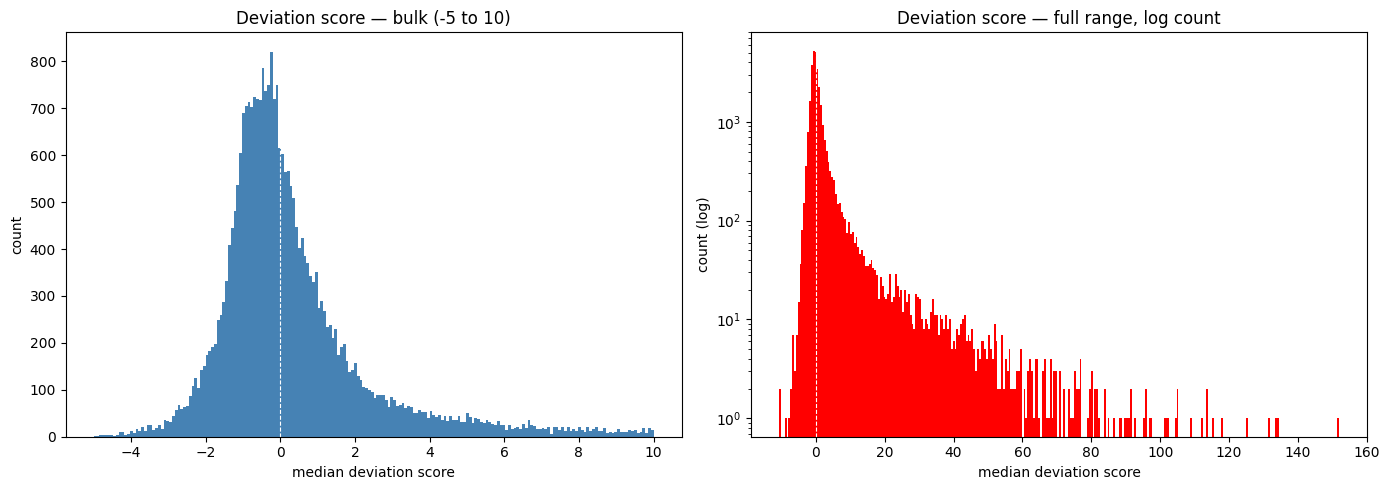

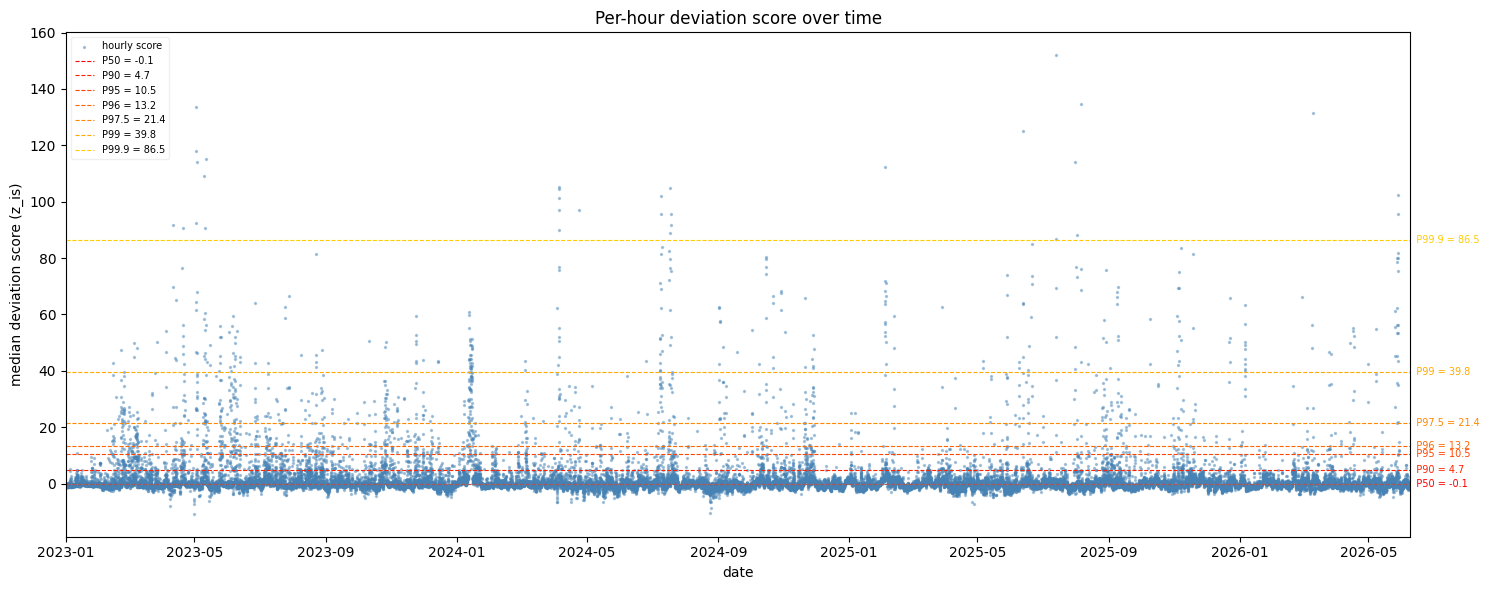

count    30117.000000
mean         1.721816
std          7.726891
min        -10.678899
25%         -0.839867
50%         -0.078439
75%          1.213488
max        151.937767
Name: median_deviation_score, dtype: float64
skew: 6.86 | kurtosis: 65.25
0.500    -0.08
0.900     4.72
0.950    10.53
0.960    13.21
0.975    21.42
0.990    39.75
0.999    86.50
Name: median_deviation_score, dtype: float64
max: 151.9


In [200]:
s = price_rolling_median['median_deviation_score'].dropna()

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Left: the bulk — zoom to where normal hours live, linear y
ax[0].hist(s, bins=200, range=(-5, 10), color='steelblue', edgecolor='none')
ax[0].axvline(0, color='white', lw=0.8, ls='--')   # no-deviation line
ax[0].set_title('Deviation score — bulk (-5 to 10)')
ax[0].set_xlabel('median deviation score')
ax[0].set_ylabel('count')

# Right: full range, log y — so the spike tail is visible
ax[1].hist(s, bins=300, color='red', edgecolor='none')
ax[1].set_yscale('log')
ax[1].axvline(0, color='white', lw=0.8, ls='--')
ax[1].set_title('Deviation score — full range, log count')
ax[1].set_xlabel('median deviation score')
ax[1].set_ylabel('count (log)')

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(15, 6))

# scatter of every hour's score (labeled so the legend has something to show)
ax.scatter(price_rolling_median['date_he'], price_rolling_median['median_deviation_score'],
           s=2, alpha=0.4, color='steelblue', label='hourly score')

# set x-limits BEFORE reading them for label placement
ax.margins(x=0)
x_right = ax.get_xlim()[1]

# percentile ladder
qs = [.5, .9, .95, .96, .975, .99, .999]
qvals = price_rolling_median['median_deviation_score'].quantile(qs)

colors = plt.cm.autumn(np.linspace(0, 0.8, len(qs)))
for (q, v), c in zip(qvals.items(), colors):
    ax.axhline(v, color=c, lw=0.8, ls='--', label=f'P{q*100:g} = {v:.1f}')
    ax.text(x_right, v, f'  P{q*100:g} = {v:.1f}',
            va='center', ha='left', fontsize=7, color=c)

ax.axhline(0, color='gray', lw=0.5)

ax.set_title('Per-hour deviation score over time')
ax.set_xlabel('date')
ax.set_ylabel('median deviation score (z_is)')
ax.legend(loc='upper left', fontsize=7, framealpha=0.3)
plt.tight_layout()
plt.show()

# quantify what the plot is showing
print(s.describe())
print("skew:", round(s.skew(), 2), "| kurtosis:", round(s.kurtosis(), 2))
print(s.quantile([.5, .9, .95, .96, .975, .99, .999]).round(2))
print("max:", round(s.max(), 1))



In [201]:
from IPython.display import Markdown, display

q = s.quantile([.25, .75, .9, .95, .99])

para = (
    f"The bulk of the deviation score is centered near zero (median {s.median():.2f}), "
    f"but the mean sits at {s.mean():.2f}, showing the pull of the upper tail on the average. "
    f"The standard deviation is {s.std():.2f}, yet the middle 50% of scores span only about "
    f"{q[.25]:.2f} to {q[.75]:.2f}, far tighter than what the standard deviation suggests. "
    f"This reflects that most hours sit close to their hour-of-day baseline; the standard deviation is inflated "
    f"by a thin set of extreme positive scores rather than describing a typical hour. "
    f"A skew of {s.skew():.2f} and kurtosis of {s.kurtosis():.2f} confirm a distribution that is "
    f"heavily right-skewed with a fat tail. The tail's reach is visible in the upper quantiles: "
    f"the 90th percentile is {q[.9]:.2f}, the 95th jumps to {q[.95]:.2f}, and the 99th to {q[.99]:.2f}. "
    f"The histogram shows the bulk of the mass falling off by a score of about 4, so a cutoff near 10 "
    f"(roughly the 95th percentile) is a reasonable choice. It sits clearly beyond the dense core, "
    f"flagging the hours that genuinely separate from the mass, which is what we want to surface."
)

display(Markdown(para))

The bulk of the deviation score is centered near zero (median -0.08), but the mean sits at 1.72, showing the pull of the upper tail on the average. The standard deviation is 7.73, yet the middle 50% of scores span only about -0.84 to 1.21, far tighter than what the standard deviation suggests. This reflects that most hours sit close to their hour-of-day baseline; the standard deviation is inflated by a thin set of extreme positive scores rather than describing a typical hour. A skew of 6.86 and kurtosis of 65.25 confirm a distribution that is heavily right-skewed with a fat tail. The tail's reach is visible in the upper quantiles: the 90th percentile is 4.72, the 95th jumps to 10.53, and the 99th to 39.75. The histogram shows the bulk of the mass falling off by a score of about 4, so a cutoff near 10 (roughly the 95th percentile) is a reasonable choice. It sits clearly beyond the dense core, flagging the hours that genuinely separate from the mass, which is what we want to surface.

In [202]:
p95 = ddb.sql('''
    with threshold as (
        select *
        from price_rolling_median
        where median_deviation_score > (
            select quantile_cont(median_deviation_score, 0.95)
            from price_rolling_median )
    )
    select
        year(date_he)                              as year,
        count(*)                                   as n_extreme,
        min(actual_price)                          as price_min,
        quantile_cont(actual_price, 0.25)          as price_q25,
        quantile_cont(actual_price, 0.50)          as price_q5,
        quantile_cont(actual_price, 0.75)          as price_q75,
        max(actual_price)                          as price_max,
        avg(actual_price)                          as price_mean,
        stddev_samp(actual_price)                  as price_std
    from threshold
    group by year(date_he)
    order by year
''').df()

price_cap = ddb.sql('''
    select
        year(date_he) as year,
        count(*) as n_cap_hours,
        sum(case when median_deviation_score > (
                select quantile_cont(median_deviation_score, 0.95)
                from price_rolling_median)
            then 1 else 0 end)             as n_cap_flagged
    from price_rolling_median
    where actual_price >= 999.99
    group by year(date_he)
    order by year(date_he)
''')

print(p95.round(2).to_string(index=False))
print(price_cap)

 year  n_extreme  price_min  price_q25  price_q5  price_q75  price_max  price_mean  price_std
 2023        669     105.89     297.39    461.43     674.26     999.99      491.39     225.59
 2024        454      74.18     242.43    400.52     673.76     999.99      474.82     273.65
 2025        283      77.58     224.67    443.29     737.06     999.99      490.93     290.38
 2026        100      59.96     199.87    370.56     726.12     999.99      466.13     316.89
┌───────┬─────────────┬───────────────┐
│ year  │ n_cap_hours │ n_cap_flagged │
│ int64 │    int64    │    int128     │
├───────┼─────────────┼───────────────┤
│  2023 │          18 │             7 │
│  2024 │          26 │            26 │
│  2025 │           5 │             5 │
│  2026 │           2 │             2 │
└───────┴─────────────┴───────────────┘



Given that $z_i$ measures price movement relative to the hour's recent baseline, year 2023 reads as more conservative with the lowest standard deviation compared to the subsequent years. The elevated price levels reflects on the rolling median, and with capped priced at `$999.99/MWh`, the $z_i$'s tighten. That is why we only see 7 of the 18 capped priced flagged. The remaining caps occurred when that hour's recent normal was already very high. It is also worth noting the cap itself censors the data. There is no way of knowing if those prices could have gone higher had it not been for the price cap.

As price levels decline in the following years, reaching the cap price is genuinely anomalous event against a lower baseline, and the resulting $z_i$ scores are more correspondingly more extreme as evident in 2024 where all the cap hours were flagged.

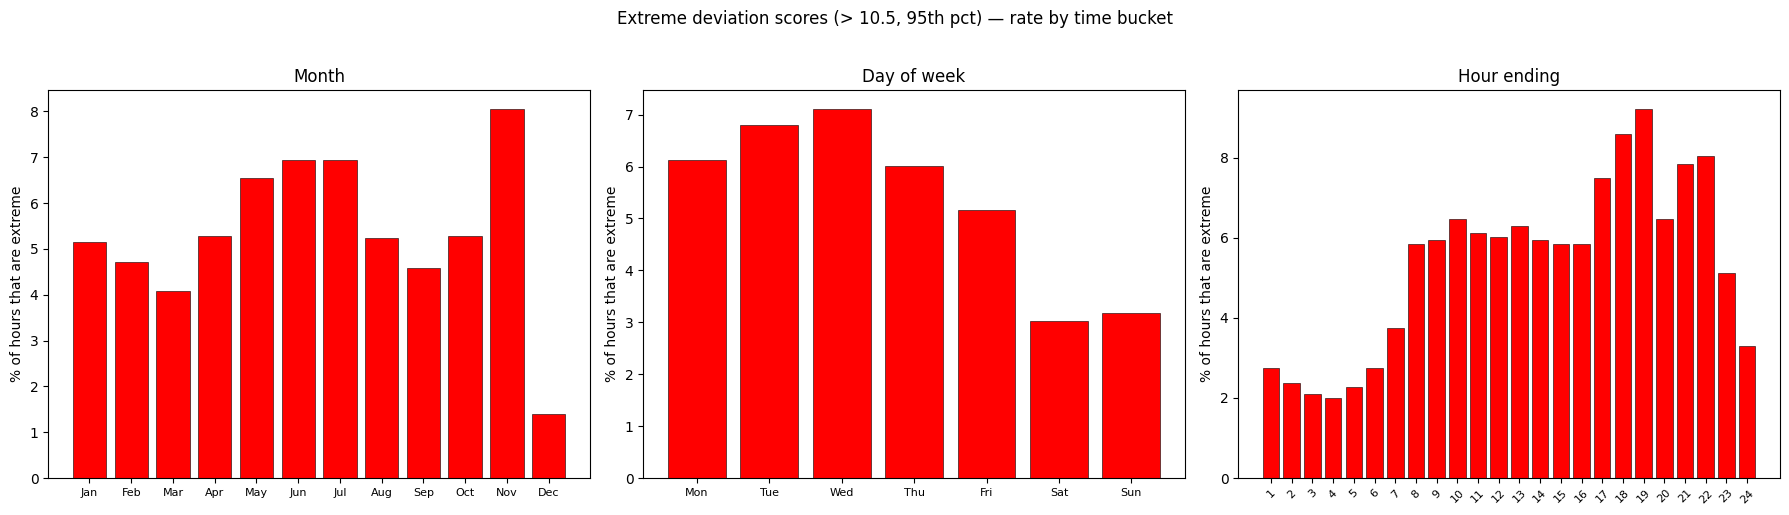

In [203]:
RATE = True   # True = extreme hours / total hours in bucket; False = raw counts

p95 = price_rolling_median['median_deviation_score'].quantile(0.95)
df = price_rolling_median.copy()
df = df[df['date_he'].dt.year.between(2023, 2025)]
df['is_ext'] = df['median_deviation_score'] > p95

df['month'] = df['date_he'].dt.month
df['dow']   = df['date_he'].dt.dayofweek
df['he']    = df['date_he'].dt.hour.replace(0, 24)   # hour-ending: 0 -> 24

dims = [
    ('month', 'Month',       list(range(1, 13)),
        ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']),
    ('dow',   'Day of week', list(range(7)), ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']),
    ('he',    'Hour ending', list(range(1, 25)), None),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (col, title, order, labels) in zip(axes, dims):
    ext   = df.loc[df['is_ext'], col].value_counts().reindex(order, fill_value=0)
    total = df[col].value_counts().reindex(order, fill_value=0)
    y = (ext / total * 100) if RATE else ext
    ax.bar(range(len(order)), y.values, color='red', edgecolor='black', linewidth=0.4)
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(labels if labels else order,
                       rotation=45 if col == 'he' else 0, fontsize=8)
    ax.set_title(title)
    ax.set_ylabel('% of hours that are extreme' if RATE else 'count of extreme hours')

fig.suptitle(f'Extreme deviation scores (> {p95:.1f}, 95th pct) — '
             f'{"rate" if RATE else "count"} by time bucket', y=1.02)
plt.tight_layout()
plt.show()

In [209]:
p_95_nov = ddb.sql('''
    with tail as (
        select date_he, actual_price, median_deviation_score
        from price_rolling_median
        where median_deviation_score > (
            select quantile_cont(median_deviation_score, 0.95)
            from price_rolling_median )
    )
    select
        year(date_he)                  as year,
        count(*)                       as n_flagged_nov,
        avg(actual_price)              as price_mean,
        avg(median_deviation_score)    as score_mean,
        max(median_deviation_score)    as score_max
    from tail
    where month(date_he) = 11
    group by year(date_he)
    order by year
''').df()

print(p_95_nov)

   year  n_flagged_nov  price_mean  score_mean  score_max
0  2023             69  373.216377   21.571786  59.318501
1  2024             62  384.162097   23.160462  65.992128
2  2025             43  431.882326   31.661654  83.727227
